In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from scipy.stats import randint

In [11]:
file_path = "Lab Session Data (1).xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="marketing_campaign"
)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully
Rows: 2240
Columns: 29


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [12]:
print("Columns in marketing_campaign dataset:")
print(df.columns.tolist())

Columns in marketing_campaign dataset:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [13]:
# ============================================================
# LAB 07 - DECISION TREE FUNCTIONS
# ============================================================

def calculate_entropy(values):
    """
    Calculate entropy of a categorical variable.
    """

    values = pd.Series(values).dropna()

    probabilities = values.value_counts(
        normalize=True
    )

    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    return float(entropy)


def calculate_gini(values):
    """
    Calculate Gini impurity of a categorical variable.
    """

    values = pd.Series(values).dropna()

    probabilities = values.value_counts(
        normalize=True
    )

    gini = 1 - np.sum(
        probabilities ** 2
    )

    return float(gini)


def bin_feature(
    series,
    bins=4,
    method="equal_width"
):
    """
    Convert a numerical feature into categorical bins.

    method = 'equal_width'
        Equal-width binning.

    method = 'frequency'
        Equal-frequency binning.
    """

    series = pd.Series(series).copy()

    series = series.fillna(
        series.median()
    )

    if method == "equal_width":

        binned = pd.cut(
            series,
            bins=bins,
            include_lowest=True
        )

    elif method == "frequency":

        binned = pd.qcut(
            series,
            q=bins,
            duplicates="drop"
        )

    else:

        raise ValueError(
            "method must be 'equal_width' "
            "or 'frequency'"
        )

    return binned.astype(str)


def calculate_information_gain(
    feature,
    target
):
    """
    Calculate Information Gain.

    Information Gain =
    Entropy(target) - Conditional Entropy(target | feature)
    """

    feature = pd.Series(
        feature
    ).reset_index(drop=True)

    target = pd.Series(
        target
    ).reset_index(drop=True)

    total_entropy = calculate_entropy(
        target
    )

    conditional_entropy = 0.0

    for value in feature.unique():

        mask = feature == value

        subset_target = target[mask]

        probability = (
            len(subset_target)
            / len(target)
        )

        conditional_entropy += (
            probability
            * calculate_entropy(
                subset_target
            )
        )

    information_gain = (
        total_entropy
        - conditional_entropy
    )

    return float(information_gain)


def find_root_feature(
    data,
    target,
    features
):
    """
    Find the feature with the highest
    Information Gain.

    Numerical features are converted
    into 4 equal-width bins.
    """

    information_gains = {}

    for feature in features:

        feature_data = data[
            feature
        ].copy()

        if pd.api.types.is_numeric_dtype(
            feature_data
        ):

            feature_data = bin_feature(
                feature_data,
                bins=4,
                method="equal_width"
            )

        else:

            feature_data = (
                feature_data
                .fillna("Unknown")
                .astype(str)
            )

        information_gains[feature] = (
            calculate_information_gain(
                feature_data,
                data[target]
            )
        )

    result = pd.DataFrame(
        information_gains.items(),
        columns=[
            "Feature",
            "Information_Gain"
        ]
    )

    result = result.sort_values(
        by="Information_Gain",
        ascending=False
    ).reset_index(drop=True)

    return result

In [14]:
print("All functions loaded successfully.")

All functions loaded successfully.


In [15]:
entropy_value = calculate_entropy(
    df["Response"]
)

print("A1 - Entropy")
print("-------------")
print(f"Entropy of Response = {entropy_value:.6f}")

A1 - Entropy
-------------
Entropy of Response = 0.607601


In [16]:
gini_value = calculate_gini(
    df["Response"]
)

print("A2 - Gini Index")
print("----------------")
print(f"Gini Index of Response = {gini_value:.6f}")

A2 - Gini Index
----------------
Gini Index of Response = 0.253748


In [17]:
target = "Response"

candidate_features = [
    "Year_Birth",
    "Education",
    "Marital_Status",
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "Complain"
]

print("Candidate features loaded successfully.")
print("Number of features:", len(candidate_features))

Candidate features loaded successfully.
Number of features: 24


In [18]:
gain_table = find_root_feature(
    df,
    target,
    candidate_features
)

print("A3 - Information Gain")
print("=====================")

display(gain_table)

A3 - Information Gain


,Feature,Information_Gain
0,AcceptedCmp5,0.054235
1,AcceptedCmp1,0.043976
2,MntWines,0.035796
3,AcceptedCmp3,0.034283
4,MntMeatProducts,0.031597
5,Recency,0.027618
6,Teenhome,0.019365
7,AcceptedCmp4,0.017710
8,Marital_Status,0.016461
9,NumCatalogPurchases,0.014471


In [19]:
root_feature = gain_table.iloc[0]["Feature"]
root_gain = gain_table.iloc[0]["Information_Gain"]

print("A3 - Root Node")
print("===============")
print("Root Feature:", root_feature)
print(f"Information Gain: {root_gain:.6f}")

A3 - Root Node
Root Feature: AcceptedCmp5
Information Gain: 0.054235


In [20]:
income_equal_width = bin_feature(
    df["Income"],
    bins=4,
    method="equal_width"
)

print("A4 - Equal-Width Binning")
print("========================")
print("Income divided into 4 equal-width bins:")
print()

display(
    income_equal_width.value_counts().sort_index()
)

A4 - Equal-Width Binning
Income divided into 4 equal-width bins:



Income
(1065.063, 167964.0]    2239
(500432.0, 666666.0]       1
Name: count, dtype: int64

In [21]:
income_equal_frequency = bin_feature(
    df["Income"],
    bins=4,
    method="frequency"
)

print("A4 - Equal-Frequency Binning")
print("============================")
print("Income divided into 4 equal-frequency bins:")
print()

display(
    income_equal_frequency.value_counts().sort_index()
)

A4 - Equal-Frequency Binning
Income divided into 4 equal-frequency bins:



Income
(1729.999, 35538.75]    560
(35538.75, 51381.5]     572
(51381.5, 68289.75]     548
(68289.75, 666666.0]    560
Name: count, dtype: int64

In [22]:
tree_features = [
    "Income",
    "Recency",
    "MntWines",
    "NumWebPurchases",
    "NumStorePurchases"
]

X = df[tree_features].copy()
y = df["Response"].copy()

print("A5 - Decision Tree Data Preparation")
print("===================================")
print("Features:", tree_features)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", sorted(y.unique()))

A5 - Decision Tree Data Preparation
Features: ['Income', 'Recency', 'MntWines', 'NumWebPurchases', 'NumStorePurchases']
X shape: (2240, 5)
y shape: (2240,)
Target classes: [np.int64(0), np.int64(1)]


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("A5 - Train/Test Split")
print("=====================")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Training features:", X_train.shape[1])

A5 - Train/Test Split
Training samples: 1792
Testing samples : 448
Training features: 5


In [24]:
decision_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

print("A5 - Decision Tree Training")
print("===========================")
print("Decision Tree trained successfully.")
print("Tree depth:", decision_tree.get_depth())
print("Number of leaves:", decision_tree.get_n_leaves())

A5 - Decision Tree Training
Decision Tree trained successfully.
Tree depth: 4
Number of leaves: 16


In [25]:
y_pred = decision_tree.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("A5 - Decision Tree Evaluation")
print("=============================")
print(f"Accuracy: {accuracy:.4f}")
print()
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

A5 - Decision Tree Evaluation
Accuracy: 0.8527

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       381
           1       0.54      0.10      0.17        67

    accuracy                           0.85       448
   macro avg       0.70      0.54      0.55       448
weighted avg       0.81      0.85      0.81       448



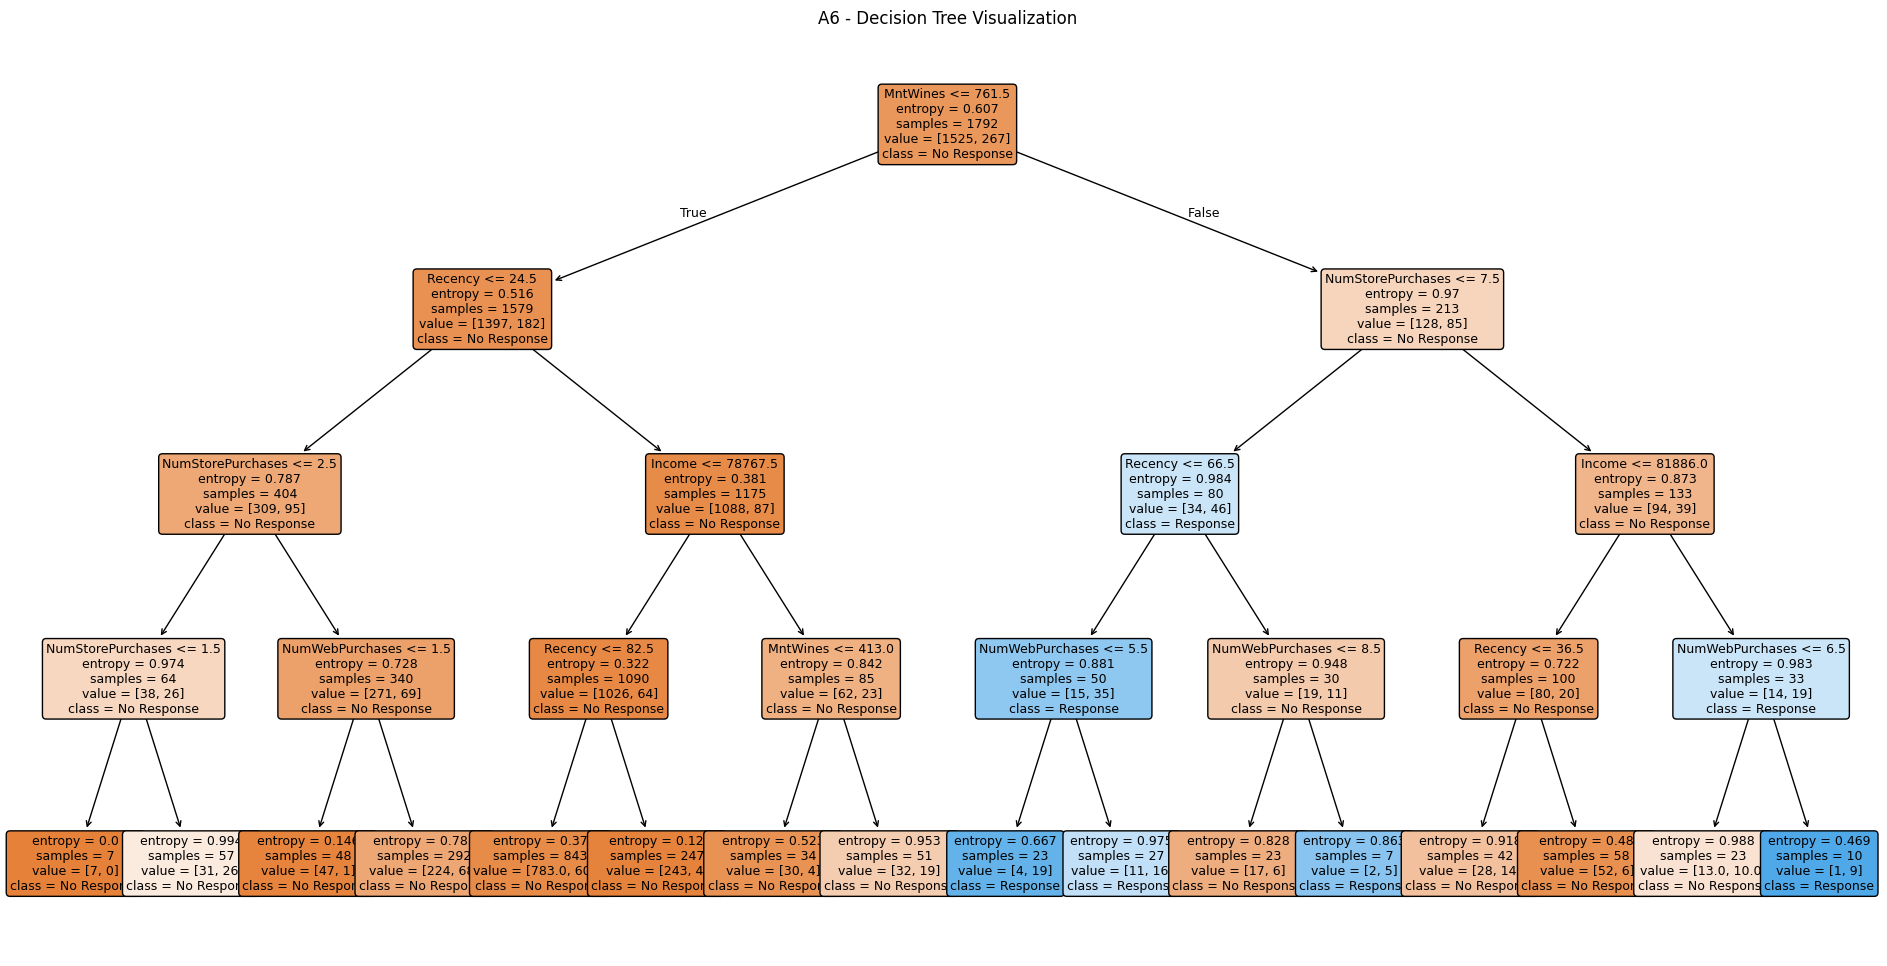

In [34]:
plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree,
    feature_names=tree_features,
    class_names=["No Response", "Response"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("A6 - Decision Tree Visualization")

plt.savefig(
    "decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
X_boundary = df[
    ["Income", "Recency"]
].copy()

y_boundary = df[
    "Response"
].copy()

print("A7 - Decision Boundary Data")
print("===========================")
print("Features:", ["Income", "Recency"])
print("Number of samples:", len(X_boundary))
print("Classes:", sorted(y_boundary.unique()))

A7 - Decision Boundary Data
Features: ['Income', 'Recency']
Number of samples: 2240
Classes: [np.int64(0), np.int64(1)]


In [28]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_boundary,
    y_boundary,
    test_size=0.20,
    random_state=42,
    stratify=y_boundary
)

boundary_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

boundary_tree.fit(
    Xb_train,
    yb_train
)

print("A7 - Two-Feature Decision Tree")
print("==============================")
print("Features: Income, Recency")
print("Tree trained successfully.")
print("Tree depth:", boundary_tree.get_depth())

A7 - Two-Feature Decision Tree
Features: Income, Recency
Tree trained successfully.
Tree depth: 4


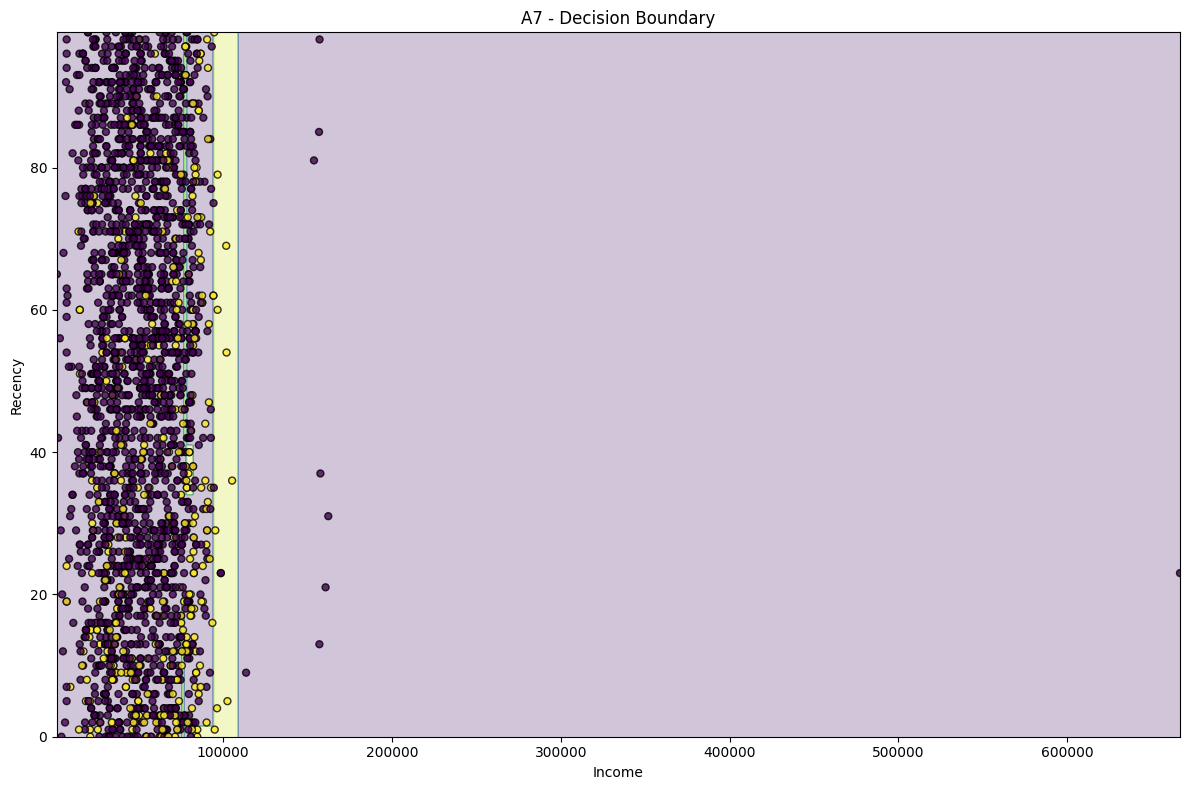

In [36]:
# ============================================================
# A7 - DECISION BOUNDARY
# ============================================================

# Select the two features
feature_x = "Income"
feature_y = "Recency"

X_boundary = df[
    [feature_x, feature_y]
].copy()

y_boundary = df[
    "Response"
].copy()

# Handle missing values
X_boundary = X_boundary.fillna(
    X_boundary.median()
)

# Train Decision Tree using the two selected features
boundary_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

boundary_tree.fit(
    X_boundary,
    y_boundary
)

# Create a grid covering the feature space
x_min = X_boundary[feature_x].min()
x_max = X_boundary[feature_x].max()

y_min = X_boundary[feature_y].min()
y_max = X_boundary[feature_y].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Create grid as a DataFrame
# This keeps the feature names consistent with training
grid_points = pd.DataFrame(
    {
        feature_x: xx.ravel(),
        feature_y: yy.ravel()
    }
)

# Predict the class for every point in the grid
Z = boundary_tree.predict(
    grid_points
)

Z = Z.reshape(
    xx.shape
)

# Create the decision-boundary plot
plt.figure(
    figsize=(12, 8)
)

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

# Plot actual observations
plt.scatter(
    X_boundary[feature_x],
    X_boundary[feature_y],
    c=y_boundary,
    edgecolors="black",
    s=25,
    alpha=0.8
)

plt.xlabel("Income")
plt.ylabel("Recency")
plt.title("A7 - Decision Boundary")

plt.tight_layout()

# Save high-resolution image for the report
plt.savefig(
    "decision_boundary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
param_distributions = {
    "max_depth": randint(2, 11),
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 11)
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

print("A8 - RandomizedSearchCV")
print("=======================")
print("Best Parameters:")
print(random_search.best_params_)
print()
print(f"Best Cross-Validation Accuracy: {random_search.best_score_:.4f}")

A8 - RandomizedSearchCV
Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 15}

Best Cross-Validation Accuracy: 0.8527


In [32]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("A8 - GridSearchCV")
print("=================")
print("Best Parameters:")
print(grid_search.best_params_)
print()
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

A8 - GridSearchCV
Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy: 0.8527


In [33]:
best_tree = grid_search.best_estimator_

y_tuned_pred = best_tree.predict(
    X_test
)

tuned_accuracy = accuracy_score(
    y_test,
    y_tuned_pred
)

print("A8 - Tuned Decision Tree Evaluation")
print("===================================")
print(f"Test Accuracy: {tuned_accuracy:.4f}")
print()
print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_tuned_pred
    )
)
print()
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_tuned_pred
    )
)

A8 - Tuned Decision Tree Evaluation
Test Accuracy: 0.8482

Confusion Matrix:
[[367  14]
 [ 54  13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92       381
           1       0.48      0.19      0.28        67

    accuracy                           0.85       448
   macro avg       0.68      0.58      0.60       448
weighted avg       0.81      0.85      0.82       448

